<a href="https://colab.research.google.com/github/Tommy-Burns/Machine_Learning_Project/blob/main/EuroCropMilestone1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Crop Type Classification from Sentinel-2 Time Series**

EuroCropsML combines EuroCrops (v9) parcel data with 2021 Sentinel-2 reflectance data from Latvia, Portugal, and Estonia for few-shot crop classification benchmarking


## Installations

In [ ]:
!pip install -q huggingface_hub

## Imports

In [ ]:
from huggingface_hub import hf_hub_download
import zipfile, io
import numpy as np
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

## Helper Functions


In [ ]:
FILES = {
    "preprocess": "preprocess/portugal.zip",
    "raw": "raw_data/Portugal.parquet",
    "labels": "raw_data/labels/Portugal_labels.parquet",
    "geometry": "raw_data/geometries/Portugal.geojson",
    "classes": "cropclasses.csv",
}

def fetch_data(file_name, data_dir="data/eurocropsml"):
    path = Path(data_dir) / FILES[file_name]

    if not path.exists():
      path = Path(
          hf_hub_download(
              repo_id="tbbotchwey/eurocropsml",
              filename=FILES[file_name],
              repo_type="dataset",
              local_dir=data_dir,
          )
        )
    if file_name == "preprocess":
      return zipfile.ZipFile(path)
    if file_name == "geometry":
      return gpd.read_file(path)
    if file_name == "classes":
      return pd.read_csv(path)
    return pd.read_parquet(path)


# GLOBAL FILENAMES
preprocess = fetch_data("preprocess")
raw     = fetch_data("raw")
labels  = fetch_data("labels")
geo     = fetch_data("geometry")
classes = fetch_data("classes")

In [ ]:
from tqdm.notebook import tqdm

BANDS = ["B01", "B02", "B03", "B04", "B05", "B06", "B07",
         "B08", "B8A", "B09", "B10", "B11", "B12"]

def all_zero(data, bands):
    idx = [BANDS.index(b) for b in bands]
    return np.all(data[:, idx] == 0, axis=1)

all_npz_files = sorted(n for n in preprocess.namelist() if n.endswith(".npz"))

npz_files, parcels, dates, values = [], [], [], []

for name in tqdm(all_npz_files, desc="Reading NPZ files"):
    file_name = Path(name).name
    nuts3, parcel_id, hcat_code = file_name[:-4].split("_")

    with np.load(io.BytesIO(preprocess.read(name))) as npz:
        data = npz["data"].astype(np.int16)
        parcel_dates = npz["dates"]

        # invalid if B02/B03/B04 are all 0, OR B05/B06/B07 are all 0
        invalid = all_zero(data, ("B02", "B03", "B04")) | all_zero(data, ("B05", "B06", "B07"))
        valid_dates = ~invalid

        if not valid_dates.any():
            continue

        data = data[valid_dates]
        parcel_dates = parcel_dates[valid_dates]

        lon, lat = npz["center"]

        npz_files.append(file_name) #npz_files.append(name)
        parcels.append((int(parcel_id), file_name, lon, lat,
                        int(hcat_code), nuts3, len(parcel_dates)))
        dates.append(parcel_dates)
        values.append(data)

parcels = pd.DataFrame(
    parcels,
    columns=["parcel_id", "file_name", "midpoint_lon", "midpoint_lat",
             "hcat_crop_code", "nuts3", "n_observations"]
)

print(f"Dropped {len(all_npz_files) - len(npz_files):,} parcels with no valid dates")
print(f"{len(parcels):,} parcels, {parcels['n_observations'].sum():,} observations")

Reading NPZ files:   0%|          | 0/99634 [00:00<?, ?it/s]

Dropped 4,932 parcels with no valid dates
94,702 parcels, 5,652,716 observations


In [ ]:
BIN_SIZES = [1, 5, 10, 15]
THRESHOLDS = [0.80, 0.85, 0.90, 0.95]

UNKNOWN_CODE = "3399000000"   # not_known

def hcat3(name: str) -> str:
    return name.rsplit("/", 1)[-1].removesuffix(".npz").rsplit("_", 1)[-1]

def summarize_dates2(files, dates_per_file, bin_sizes = BIN_SIZES, thrs = THRESHOLDS, label="Portugal", show=True, unknown_always_kept=False):
    n_files = len(files)

    known = np.array([hcat3(f) != UNKNOWN_CODE for f in files])
    n_known = int(known.sum())

    lengths = np.fromiter(map(len, dates_per_file), dtype=int, count=n_files)
    all_dates = np.concatenate(dates_per_file)
    file_idx = np.repeat(np.arange(n_files), lengths)

    origin = all_dates.min()
    offsets = (all_dates - origin).astype(int)
    n_days = offsets.max() + 1

    results = {}
    kept_files = {}
    for size in bin_sizes:
        n_bins = -(-n_days // size)
        presence = np.zeros((n_files, n_bins), dtype=bool)
        presence[file_idx, offsets // size] = True
        known_counts = presence[known].sum(axis=0)

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.bar(np.arange(n_bins), known_counts)
        for t in thrs:
            ax.axhline(t * n_known, ls="--",
                      label=f"{int(t*100)}% ({t*n_known:.1f} known files)")
        ax.set(title=f"{label}: files with ≥1 date per {size}-day group",
               xlabel=f"{size}-day group index (from {origin})",
               ylabel="Number of known files")
        ax.legend()
        fig.tight_layout()
        plt.show() if show else plt.close(fig)

        for t in thrs:
            kept_bins = known_counts >= t * n_known
            kept_mask = presence[:, kept_bins].all(axis=1)   # applies to all files
            if unknown_always_kept:
                kept_mask |= ~known
            results[(size, t)] = int(kept_mask.sum())
            kept_files[(size, t)] = [f for f, k in zip(files, kept_mask) if k]
            n_kept_known = int((kept_mask & known).sum())
            print(f"[{label}] {size}-day, ≥{int(t*100)}% of known: "
                  f"{kept_bins.sum()} bins kept, "
                  f"{n_kept_known}/{n_known} known + "
                  f"{results[(size, t)] - n_kept_known}/{n_files - n_known} not_known files kept")

    return {"n_files": n_files, "n_known": n_known, "files": files,
            "all_dates": all_dates, "results": results, "kept_files": kept_files}

In [ ]:
kept = pt_dic2["kept_files"][(15, 0.85)]

l6_code_to_name = dict(
    zip(
        classes["HCAT3_level6_code"].astype(str).str.strip(),
        classes["HCAT3_level6_name"].astype(str).str.strip()
    )
)

l3_code_to_name = dict(
    zip(
        classes["HCAT3_level3_code"].astype(str).str.strip().str[:-6],
        classes["HCAT3_level3_name"].astype(str).str.strip()
    )
)

In [ ]:
from matplotlib.patches import Patch

# one stable color per level 3 category, built from the full set
all_l3 = np.unique([hcat3(n)[:4] for n in pt_dic2["files"]])
cmap = plt.get_cmap("tab20")
l3_color = {k: cmap(i % cmap.N) for i, k in enumerate(all_l3)}

def plot_top_classes_color_l3(names, title, top_n=25):
    codes = np.array([hcat3(n) for n in names])
    cls_u, n_u = np.unique(codes, return_counts=True)
    order = np.argsort(-n_u)[:top_n]

    top_codes = cls_u[order]
    top_names = [l6_code_to_name.get(c, c) for c in top_codes]
    top_l3 = [c[:4] for c in top_codes]
    colors = [l3_color[k] for k in top_l3]

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(top_names, n_u[order], color=colors)
    ax.set_xscale("log")
    ax.set_xlim(right=max(n_u[order]) * 2) #to avoid the number on the top bar from going overboard
    ax.invert_yaxis()
    ax.bar_label(bars, padding=3)
    ax.set(title=title, xlabel="Number of parcels (log scale)", ylabel="Crop type")
    ax.grid(axis="x", which="major", ls=":", alpha=0.5)
    ax.set_axisbelow(True)

    # legend only for the level 3 categories present in this plot, in order of appearance
    present = list(dict.fromkeys(top_l3))

    ax.legend(
        handles=[
            Patch(
                color=l3_color[k],
                label=l3_code_to_name.get(k, k)
            )
            for k in present
        ],
        title="Level 3 category",
        loc="lower right"
    )

    fig.tight_layout()
    plt.show()

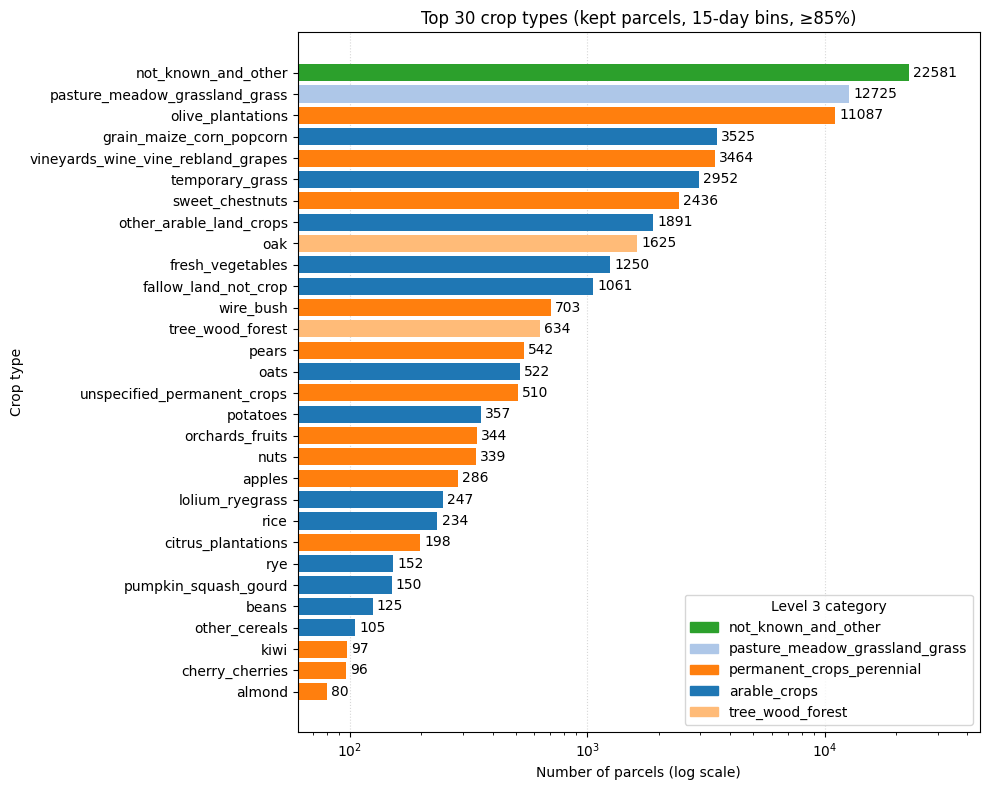

In [ ]:
plot_top_classes_color_l3(kept, "Top 30 crop types (kept parcels, 15-day bins, ≥85%)", 30)

#**Data Introduction**



### **1.1 How and Why data was collected**
The data comes from **EuroCropsML**, developed by TU Munich and Dida within the PretrainAppEO project.
It uses data from two sources:
- Labels from Eurocrops (V9), which is an open collection of agricultural reference data from EU countries
- Satellite observations from Sentinel-2 L1C top of atmosphere reflectance for 2021, aggregated per parcel as the median pixel value inside the parcel geometry

**EuroCropsML** was built as a benchmark for few-shot crop type classification in 3 countries, but for our project we use it as a standard supervised classification dataset on one country: Portugal.

The data is as follows:
- **Raw data:** Contains parquet for each country, labels and geometries (all observations)
- **Preprocessed data:**
    - Ready to use .npz files, one per data point with metdata (parcel centre, dates and data)
    - Clouds have been removed
    - file names follow the pattern "[NUTS3-region]\_[parcelID]\_[HCAT-code].npz" ( e.g. "PT16E_1196198_3399000000.npz")
- **Split data:** json files that divide the preprocessed files into a pre-training (train and validation set) set and a fine tuning (train,validation, test) set for 2 scenarios:
    - latvia_portugal_vs_estonia: pre-training on Latvia and Portugal, fine-tuning on Estonia
    - latvia_vs_estonia: pre-training on Latvia and fine-tuning on Estonia

Since we were not interested in any of the scenarios provided by the split data, we decided to work with the preprocessed data.

**Geographic Coverage:** Latitude 37.3 to 42.1 and longitude -9.45 to -6.47 which covers the portugal mainland and not the islands

### **1.2 Application Domain**
Agricultural monitoring with Earth Observation

### **1.2 Learning Task**
Supervised multi-class Crop type classification: for every parcel based on its annual Sentinel-2 time series, we predict its crop type

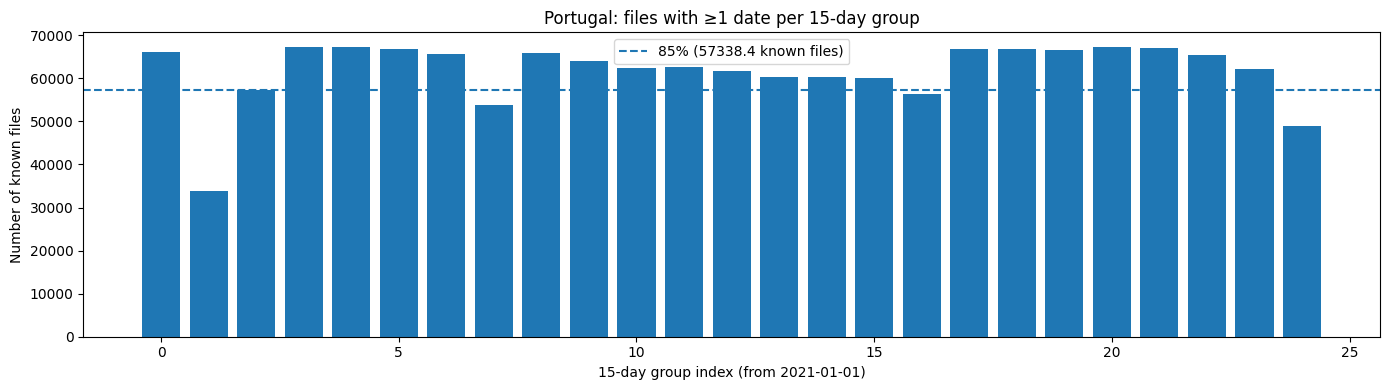

[Portugal] 15-day, ≥85% of known: 20 bins kept, 48269/67457 known + 22581/27245 not_known files kept


In [ ]:
pt_dic2 = summarize_dates2(npz_files, dates, [15], [0.85])

### **1.3 Features**
Each parcel is stored as one .npz file with three arrays
- Data: A list of various observation dates * 13 Sentinel-2 Bands, consisting of non-negative refectance values
- Dates: Acquisition date of each row
- Center: Parcel centroid

After carefully analyzing the data, we decided to aggregate the dates in 15-day intervals (as shown in the figure above), to ensure that all the samples would have the same features. Furthermore, we also dropped 3 Bands (B01, B09 and B10), since a large number of parcels were missing data for these, and they are not paramount for vegetation classification. Thus, the final list of features should contain a column for each of the 10 remaining band for each of our 20 15-day intervals.

### **1.4 Output Variable**
The HCAT crop type of a parcel, a nominal categorical variable (multi-class, no ranking, classification), which means our project should be able to give one label output from a fixed list of crop type.

# **Data Description**

<img src="https://i.imgur.com/2rwa3O5.png" width="400">

Potential Pre-processing
- We choose to use stratified shuffled sampling with a seed (specified random state) to ensure reproducibility. Since we have no data in the islands, this should be enough to get diversified samples.
- As mentioned before, we have also aggregated the data by 15-day periods, which meant we had to calculate the average of observations that fell inside the same period.
- Since we are only using Sentinel-2 band values, there should be no need to scale the data, regardless of the model used.


# **Evaluation Protocol**

Our goal is to build a model that is able to predict the crop type of parcels it has never seen, without information leaking from test to training.

### **4.1 Data Splitting**
- Test set: 70%
- Test 10%
- Validation 20%

We plan to use the cross validation, we are yet to decide on the folds but we will start with the default 5, where we have 4 training folds and one hold out


### **4.2 Hyperparameter Tuning**
For each algorithm we will identify its man hyperparameters e.g number of tress for random forest

### **4.3 Planned Algorithms**
- K-Neighbors
- Random Forest
- SVM

### **4.4 Evaluation Metrics**
For numbers we measure how far off the guess of our model is, but since ours is a crop label, we measure how often it is right and for which crops hence accuracy and recall for each crop type or a combination of both (since the model could be good at big classes and bad at the small classes) will be the classification metrics used.